In [1]:
from sdk_core import configure
from sdk_core import TwMarketData
# configure()

tw = TwMarketData()
# 取得還原股價
df = tw.get_security_price_adjusted("2025-12-31", "2330")

import os
import numpy as np
from tqdm import tqdm
import time
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
# 將最大顯示欄位數量設為 None（代表無上限）
pd.set_option('display.max_columns', None)

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

from backTest import BackTest
from factorAnalyzer import FactorAnalyzer_Polars


/home/kevin/project/HFTResearch/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

folder_path = './data'  # 資料夾路徑
files = os.listdir(folder_path)

# 過濾掉資料夾，只留下檔案
file_names = np.array([f for f in files if os.path.isfile(os.path.join(folder_path, f))])
file_names.sort()
print(file_names[-5:])

['20260225.parquet' '20260226.parquet' '20260302.parquet'
 '20260303.parquet' '20260304.parquet']


In [3]:
data = []

# 範例：處理 100 個檔案
for f in tqdm (file_names[1:]): 
    targetLabel = 'BidPrice1' 
    rankThres_btn = 0
    rankThres = 100.1
    stock_df = pd.read_parquet( f'{folder_path}/{f}' )[lambda x : x[targetLabel] * x.BidPrice1 > 0]
    try : 
        stock_df['ToRef'] = (stock_df['BidPrice1'] - stock_df.RefPrice) / stock_df.RefPrice 
        stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.09 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.FutureHigh) / stock_df[targetLabel] * 10000)
        PriceCondition = (stock_df.ToRef > 0) & (stock_df.ToRef < 0.05)
        AmountCondition = (stock_df.day_amount_rank <= rankThres) | (stock_df.AmountRank <= rankThres) 
        # AmountCondition2 = (stock_df.day_amount_rank > rankThres_btn) & (stock_df.AmountRank > rankThres_btn)
        # preMarketCondition = (stock_df.day_amount_rank <= 50.1) | (stock_df.AmountRank <= 50.1)
        temp = stock_df[ PriceCondition & AmountCondition ].reset_index(drop=True)
        temp['Date'] = f.split('.')[0]
        data.append(temp)
    except : 
        print('Filled in ', f)
        continue
    # break

100%|██████████| 755/755 [00:58<00:00, 12.89it/s]


In [4]:
signal_df = pd.concat(data).reset_index(drop=True)

In [5]:
priceReturnColumn = ["TransTime", "QuoteCode", "ChannelSeq","TotalFillLots","BidPrice1","BidLots1", "AskPrice1","AskLots1", "RecordHigh","FutureHigh", "RefPrice" , "Close" , "Open", "Spread", "TakerSell_CloseBP" ]
signal_df[:][priceReturnColumn + ['ToRef','FillLots_atLow','day_amount_rank', 'AmountRank', 'TimeSlot','TransTime_tb']].head(10)

,TransTime,QuoteCode,ChannelSeq,TotalFillLots,BidPrice1,BidLots1,AskPrice1,AskLots1,RecordHigh,FutureHigh,RefPrice,Close,Open,Spread,TakerSell_CloseBP,ToRef,FillLots_atLow,day_amount_rank,AmountRank,TimeSlot,TransTime_tb
0,2023-01-10 09:05:43.411922,1216,381477,207,67.60,2,67.70,201,67.7,67.6,67.6,67.1,67.6,1.0,73.964497,2.102197e-16,-29,61.0,267.0,09:05:00,2023-01-10 09:04:56.812278
1,2023-01-10 09:01:49.567847,1301,185560,115,89.10,3,89.20,1,89.3,89.2,88.9,88.9,89.2,1.0,22.446689,2.249719e-03,-19,50.0,NaN,None,NaT
2,2023-01-10 09:02:57.607675,1301,248120,132,89.00,17,89.10,3,89.3,89.1,88.9,88.9,89.2,1.0,11.235955,1.124859e-03,-13,50.0,NaN,None,NaT
3,2023-01-10 09:07:21.257404,1305,454649,3648,27.30,19,27.40,27,28.4,28.2,26.8,28.0,27.5,2.0,-256.410256,1.865672e-02,-9,310.0,26.0,09:05:00,2023-01-10 09:04:58.421785
4,2023-01-10 09:07:21.305388,1305,454692,3648,27.30,19,27.35,1,28.4,28.2,26.8,28.0,27.5,1.0,-256.410256,1.865672e-02,-9,310.0,26.0,09:05:00,2023-01-10 09:04:58.421785
5,2023-01-10 09:07:24.087279,1305,456759,3690,27.20,25,27.35,3,28.4,28.2,26.8,28.0,27.5,3.0,-294.117647,1.492537e-02,-20,310.0,26.0,09:05:00,2023-01-10 09:04:58.421785
6,2023-01-10 09:07:24.130405,1305,456805,3690,27.20,21,27.30,1,28.4,28.2,26.8,28.0,27.5,2.0,-294.117647,1.492537e-02,-20,310.0,26.0,09:05:00,2023-01-10 09:04:58.421785
7,2023-01-10 09:07:24.818537,1305,457306,3690,27.20,21,27.25,1,28.4,28.2,26.8,28.0,27.5,1.0,-294.117647,1.492537e-02,-20,310.0,26.0,09:05:00,2023-01-10 09:04:58.421785
8,2023-01-10 09:07:24.845775,1305,457318,3691,27.20,21,27.30,1,28.4,28.2,26.8,28.0,27.5,2.0,-294.117647,1.492537e-02,-19,310.0,26.0,09:05:00,2023-01-10 09:04:58.421785
9,2023-01-10 09:07:24.913715,1305,457373,3712,27.15,7,27.30,1,28.4,28.2,26.8,28.0,27.5,3.0,-313.075506,1.305970e-02,-40,310.0,26.0,09:05:00,2023-01-10 09:04:58.421785


In [6]:
# target_time_str = "13:25:00"
# target_dt = pd.to_datetime(signal_df['TransTime'].dt.date.astype(str) + " " + target_time_str)
# signal_df['RemainSeconds'] = (target_dt - signal_df['TransTime']).dt.total_seconds()
signal_df = signal_df[ (signal_df.TransTime.dt.time < datetime.time(12, 0, 0)) & (signal_df.TrialMatch == 0)].reset_index(drop=True)
signal_df = signal_df[  ((signal_df.Date.astype(int) - 20260220).abs() > 5 )& (signal_df.TakerSell_CloseBP.abs() < 10000) ].reset_index(drop=True)
signal_df['midEdge_300sBP'] = signal_df['midEdge_300sBP']*-1

In [7]:
signal_df.head(1)

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,Date,trading_net_volume_noOdd,trading_net_volume_nearClose,avg_bidLots1,avg_askLots1,last_fillLots,last_FillPrice,premium_ref_2330_buy_ToCloseBP,premium_open_2330_buy_ToCloseBP,discount_ref_2330_buy_ToCloseBP,discount_open_2330_buy_ToCloseBP
0,2023-01-10 09:05:43.411922,2023-01-10 09:05:43.411922,1216,1216,1041246,381477,0,0,0,0,207,67.6,67.5,67.4,67.3,67.2,2,12,2,14,47,67.7,67.8,67.9,68.0,68.1,201,84,68,295,64,0.0,0,0.0,0,0.0,0,NaN,67.6,False,True,67.6,67.1,67.7,67.5,67.6,66.7,0.001479,0.001479,0.5,0.1,14.792899,67.65,2.102197e-16,0.00074,-29,-68,43,0.009852,0.025974,0.181818,0.282303,0.400281,1.0,1,67.7,67.5,1,0.055184,0.055184,1.0,98,109,0.0,67.5,67.4,67.5,67.4,67.5,67.4,67.3,67.2,67.3,67.2,67.3,67.2,73.964497,-88.626292,-29.563932,-29.563932,-29.563932,-59.127864,59.127864,-59.127864,X,10198983.0,16096.0,-94000.0,0.0,3885438.0,-754000.0,-38.0,-4.0,X,10115.0,842.0,-39.728946,-29.961637,10.0,-14.299677,1.131437,0.47578,-4.916421,-2.460025,-25.118628,-10.261087,-0.993135,-21.430348,-2.002026,61.0,53.0,2023-01-10 09:04:56.812278,09:05:00,267.0,69.0,298.0,81.0,985.0,829.0,523.0,442.0,277.0,290.0,20230110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
condition =  (signal_df.big_sell_ToCloseBP.abs() > 20)

<Axes: xlabel='Date'>

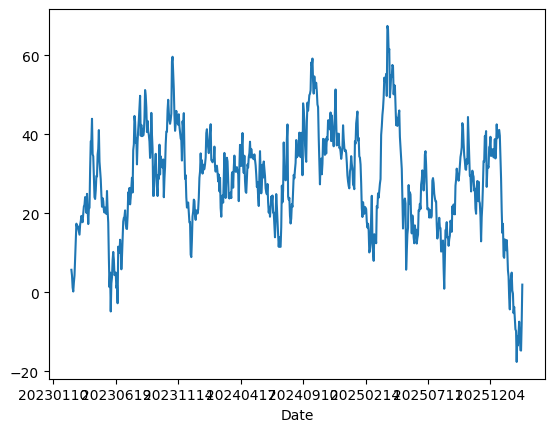

In [9]:
signal_df[:].groupby(['Date','QuoteCode']).TakerSell_CloseBP.mean().reset_index().groupby(['Date']).TakerSell_CloseBP.mean().rolling(30).mean().plot()

In [10]:
condition = ((signal_df.FillLots_atHigh.abs() > signal_df.trading_volume *0.001))

In [11]:
condition = (signal_df.hft_participation > signal_df.groupby('Date').hft_participation.transform('mean') ) 

In [12]:
signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby('Date').TakerSell_CloseBP.transform('mean')

In [13]:
signal_df.TakerSell_CloseBP .describe()

count    1.031316e+07
mean     7.892072e+01
std      2.875030e+02
min     -1.784387e+03
25%     -1.851852e+01
50%      9.687836e+01
75%      2.316602e+02
max      1.426783e+03
Name: TakerSell_CloseBP, dtype: float64

In [57]:
# ================= 使用範例 =================
# 假設 df 是您準備好的 Tick 資料
based_columns = ['QuoteCode', 'ChannelSeq', 'InOut', 'Overshoot', 'TotalFillLots', 'BidPrice1','BidLots1', 'BidLots5', 'AskPrice1', 'AskLots1', 'AskLots5', 'FillLots']
feature_columns = ['ToLow', 'ToHigh', 'Low_High', 'TickSize', 'TickBP', 'ToRef', 'ToOpen', 'FillLots_atLow', 'FillLots_atHigh', 'B1_A1B1', 'B1_B1B5', 'B12_B1B5', 'A1_A1A5', 'A12_A1A5', 'Spread', 'SpreadPairID', 'SpreadPairSeq', 'SpreadPairElapsed', 'SpreadNarrowSide', 'SpreadPairCumLots', 'PrevSpreadPairLots', 'RemainSeconds']
cross_columns = ['AmountRank', 'netAmountRank', 'TotalFillLotsRank', 'netTotalFillLotsRank', 'ToRefRank']
day_columns = ['dealer_hedging_netLots', 'dealer_netLots', 'foreign_dealer_netLots', 'foreign_netLots', 'investment_netLots', 'margin_netLots', 'short_netLots', 'nextday_allow_day_trade_mark', 'trading_volume_noOdd', 'big_buy_lots', 'big_buy_ToCloseBP', 'big_buy_300sBP', 'big_sell_lots', 'big_sell_ToCloseBP', 'big_sell_300sBP', 'hft_participation', 'hft_buy_ToCloseBP', 'hft_buy_300sBP', 'hft_sell_ToCloseBP', 'hft_sell_300sBP', 'day_amount_rank', 'day_lots_rank']
# # 
feature = based_columns + feature_columns + cross_columns + day_columns

for label in [ 'TakerSell_CloseBP_net', 'midEdge_300sBP' ] : 
    analyzer = FactorAnalyzer_Polars(signal_df, label_col=label, feature_cols=feature, time_col='Date', weight_col='BidPrice1')
    top_factors_df = analyzer.screen_single_factors(split_date='2024-01-01', n_quantiles=5, spread_threshold=40.0)
    condition_sample = (top_factors_df.Stability > 0.5) & (top_factors_df.IS_Spread * top_factors_df.IS_IC.apply(np.sign) > 40 )
    condition_weight = (top_factors_df.W_Stability > 0.5) & (top_factors_df.IS_W_Spd * top_factors_df.IS_W_IC.apply(np.sign) > 40 )
    top_factors = top_factors_df[ condition_sample | condition_weight ].Feature.to_list()
    break
    # signal_df = train_and_predict_ridge(signal_df, top_factors, label, train_date='2025-01-01')

>>> 初始化資料並轉換為 Polars 極速引擎...
✅ Polars 引擎準備完畢！資料筆數: 11,767,559 筆 | 有效特徵數: 59

🚀 開始單一因子全局海選 (Polars 極速引擎版 | 純數值輸出)
⏱️ 樣本切割點: 2024-01-01 | 🎯 過濾條件: |Spread| > 40.0


⚙️ 因子運算進度:  67%|██████▋   | 39/58 [01:42<00:47,  2.48s/it]/home/kevin/project/HFTResearch/src/research/factorAnalyzer.py:97: RuntimeWarning: invalid value encountered in scalar divide
  w_ic = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
⚙️ 因子運算進度: 100%|██████████| 58/58 [02:27<00:00,  2.55s/it]


✅ 篩選完成！共找到 7 個 Spread > 40.0 的強勢因子：

           Feature   IS_IC  OOS_IC  Stability  IS_Spread  OOS_Spread  IS_W_IC  OOS_W_IC  W_Stability  IS_W_Spd  OOS_W_Spd
             ToRef  0.2917  0.2589     0.8874     120.55      116.16   0.3052    0.2232       0.7312    130.70     110.18
        ChannelSeq -0.2469 -0.2105     0.8528     -99.84      -80.28  -0.2545   -0.1771       0.6956    -95.23     -61.82
         ToRefRank -0.1935 -0.1589     0.8212     -59.64      -40.99  -0.1820   -0.1276       0.7012    -51.81     -27.80
          AskLots5 -0.1018 -0.0658     0.6469     -51.71      -35.00  -0.0911   -0.0509       0.5588    -54.40     -28.09
PrevSpreadPairLots -0.1008 -0.0582     0.5775     -47.09      -27.52  -0.0986   -0.0445       0.4513    -54.72     -22.37
 SpreadPairCumLots -0.1001 -0.0536     0.5356     -43.90      -26.10  -0.0926   -0.0350       0.3780    -51.69     -19.74
     TotalFillLots -0.0978 -0.0287     0.2936     -40.13      -13.46  -0.0902   -0.0155       0.1721    -41.

In [58]:
    condition_sample = (top_factors_df.Stability > 0.5) & (top_factors_df.IS_Spread * top_factors_df.IS_IC.apply(np.sign) > 40 )
    condition_weight = (top_factors_df.W_Stability > 0.5) & (top_factors_df.IS_W_Spd * top_factors_df.IS_W_IC.apply(np.sign) > 40 )
    top_factors = top_factors_df[ condition_sample | condition_weight ].Feature.to_list()
    top_factors

['ToRef',
 'ChannelSeq',
 'ToRefRank',
 'AskLots5',
 'PrevSpreadPairLots',
 'SpreadPairCumLots']

In [59]:
import pandas as pd
from sklearn.linear_model import Ridge

def train_and_predict_ridge(signal_df, X_list, Y_col):
    print(f"🔍 目前預測目標: {Y_col}")
    
    # 計算 0.1% 的閾值 (threshold)
    total_rows = len(signal_df)
    threshold = total_rows * 0.01
    print(f"📊 資料總筆數: {total_rows} | 0.1% 容忍閾值: {threshold:.2f} 筆")
    
    # 建立分類清單
    cols_to_drop_rows = []
    cols_to_remove_from_X = []
    
    # ==========================================
    # 1. 檢查 X_list 裡面的 NaN 狀況並分類
    # ==========================================
    for col in X_list:
        nan_count = signal_df[col].isna().sum()
        if nan_count > 0:
            if nan_count < threshold:
                # NaN 數量小於 0.1%，標記為準備 dropna (刪除資料列)
                cols_to_drop_rows.append(col)
            else:
                # NaN 數量大於等於 0.1%，標記為準備移除特徵
                cols_to_remove_from_X.append(col)
                
    # ==========================================
    # 2. 執行移除特徵 (Columns) 動作
    # ==========================================
    # 產生真正要進模型的 current_X
    current_X = [col for col in X_list if col not in cols_to_remove_from_X]
    
    if cols_to_remove_from_X:
        print(f"⚠️ 以下特徵 NaN 數量超過閾值，已從 X_list 中移除：")
        for col in cols_to_remove_from_X:
            nan_count = signal_df[col].isna().sum()
            print(f"   - {col} (NaN: {nan_count} 筆)")
            
    # ==========================================
    # 3. 處理 Y 的 NaN 與執行 dropna (刪除資料列)
    # ==========================================
    # 確保 Y 如果有 NaN 也一併剔除該筆資料
    signal_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    if signal_df[Y_col].isna().sum() > 0 and Y_col not in cols_to_drop_rows:
        cols_to_drop_rows.append(Y_col)
        
    if cols_to_drop_rows:
        print(f"🧹 以下欄位 NaN 數量極少 (低於閾值)，將直接剔除帶有 NaN 的資料列：")
        for col in cols_to_drop_rows:
            nan_count = signal_df[col].isna().sum()
            print(f"   - {col} (NaN: {nan_count} 筆)")
            
        # 實際執行 dropna，並更新 signal_df
        signal_df = signal_df.dropna(subset=cols_to_drop_rows).copy()
        print(f"✅ 剔除後剩餘資料總筆數: {len(signal_df)}")
        
    # ==========================================
    # 4. 顯示最終要進模型的 X_list
    # ==========================================
    print("-" * 40)
    print(f"🚀 最終使用的 X_list (共 {len(current_X)} 個特徵):")
    print(current_X)
    print("-" * 40)
    
    # 安全機制：如果所有 X 都被砍光了，就拋出錯誤
    if not current_X:
        raise ValueError("所有的 X 特徵都因為 NaN 太多被移除了，無法建立模型！")

    # ==========================================
    # 5. 處理時間與切分訓練集
    # ==========================================
    train_mask = signal_df['Date'].astype(int) < 20240101
    lot_mask = signal_df.groupby(['Date','QuoteCode']).BidPrice1.cumsum()/10 < 500 
    train_df = signal_df[train_mask&lot_mask]
    
    # ==========================================
    # 6. 建立並訓練 Ridge 模型
    # ==========================================
    model = Ridge(alpha=10.0)
    model.fit(train_df[current_X], train_df[Y_col])
    
    # ==========================================
    # 7. 對整份 signal_df 進行預測
    # ==========================================
    pred_col_name = f"{Y_col}_pred"
    signal_df[pred_col_name] = model.predict(signal_df[current_X])
    
    return signal_df

In [60]:
signal_df = train_and_predict_ridge(signal_df, top_factors, label).reset_index(drop=True)

🔍 目前預測目標: TakerSell_CloseBP_net
📊 資料總筆數: 11767559 | 0.1% 容忍閾值: 117675.59 筆
⚠️ 以下特徵 NaN 數量超過閾值，已從 X_list 中移除：
   - ToRefRank (NaN: 2018145 筆)
----------------------------------------
🚀 最終使用的 X_list (共 5 個特徵):
['ToRef', 'ChannelSeq', 'AskLots5', 'PrevSpreadPairLots', 'SpreadPairCumLots']
----------------------------------------


/home/kevin/project/HFTResearch/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.419326203952914e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [61]:
signal_df.head(1)

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,RefPrice,OTC,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,FillLots_Net,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,negFill_corr,negFill_sell_ToCloseBP,negFill_sell_300sBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,ToOpenRank,ToRefWithOTCRank,ToOpenWithOTCRank,ToOpenNegativeCount,ToOpenPositiveCount,Date,TakerSell_CloseBP_net,TakerSell_CloseBP_net_pred
0,2023-01-10 09:05:43.411922,2023-01-10 09:05:43.411922,1216,1216,1041246,381477,0,0,0,0,207,67.6,67.5,67.4,67.3,67.2,2,12,2,14,47,67.7,67.8,67.9,68.0,68.1,201,84,68,295,64,0.0,0,0.0,0,0.0,0,NaN,67.6,False,True,67.6,67.1,67.7,67.5,67.6,66.7,0.001479,0.001479,0.5,0.1,14.792899,67.65,2.102197e-16,0.00074,-29,-68,43,0.009852,0.025974,0.181818,0.282303,0.400281,1.0,1,67.7,67.5,1,0.055184,0.055184,1.0,98,109,0.0,67.5,67.4,67.5,67.4,67.5,67.4,67.3,67.2,67.3,67.2,67.3,67.2,73.964497,-88.626292,-29.563932,-29.563932,-29.563932,-59.127864,-59.127864,-59.127864,X,10198983.0,16096.0,-94000.0,0.0,3885438.0,-754000.0,-38.0,-4.0,X,10115.0,842.0,-39.728946,-29.961637,10.0,-14.299677,1.131437,0.47578,-4.916421,-2.460025,-25.118628,-10.261087,-0.993135,-21.430348,-2.002026,61.0,53.0,2023-01-10 09:04:56.812278,09:05:00,267.0,69.0,298.0,81.0,985.0,829.0,523.0,442.0,277.0,290.0,20230110,3.401457,-37.559089


In [14]:
condition = pd.Series( [True for i in range(len(signal_df))] )
# condition = (signal_df.big_sell_ToCloseBP > 0 ) & (signal_df.InOut < 0 ) & (signal_df.FillLots > signal_df.big_buy_lots)
# condition = condition | ((signal_df.Spread <= 1 )&((signal_df.SpreadPairSeq<5)|(signal_df.SpreadPairID > 5)))
condition = condition #& (signal_df.TakerSell_CloseBP_net_pred > 0) #& ((signal_df.netTotalFillLotsRank>1800)|(signal_df.netAmountRank>1800))
print( signal_df[condition].TakerSell_CloseBP.describe() )
print('')
print( 'cap BP : '+str( round((signal_df[condition].TakerSell_CloseBP * signal_df[condition].BidPrice1).sum() / signal_df[condition].BidPrice1.sum() ,2 ))  )
print( 'averge prod num : '+str( round(signal_df[condition].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

condition_recent = condition & (signal_df.Date.astype(int) > 20260101) #& (signal_df.hft_participation > 0.3) & (signal_df.hft_sell_ToCloseBP > 0 )
print( signal_df[condition_recent].TakerSell_CloseBP.describe() ) 
print('')
print( 'cap BP : '+str( round((signal_df[condition_recent].TakerSell_CloseBP * signal_df[condition_recent].BidPrice1).sum() / signal_df[condition_recent].BidPrice1.sum() ,2 ))  )
print( 'averge prod num : '+str( round(signal_df[condition_recent].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

count    1.031316e+07
mean     7.892072e+01
std      2.875030e+02
min     -1.784387e+03
25%     -1.851852e+01
50%      9.687836e+01
75%      2.316602e+02
max      1.426783e+03
Name: TakerSell_CloseBP, dtype: float64

cap BP : 64.3
averge prod num : 72.4
count    660442.000000
mean         46.714229
std         401.937860
min        -998.766954
25%        -170.340681
50%          73.800738
75%         301.507538
max        1316.872428
Name: TakerSell_CloseBP, dtype: float64

cap BP : -4.87
averge prod num : 67.52


In [15]:
signal_df = signal_df[condition ].reset_index(drop=True)
# signal_df = signal_df[condition & ((signal_df.Date.astype(int) < 20260101) |( (signal_df.hft_participation > 0.3) & (signal_df.hft_sell_ToCloseBP > 0 )))].reset_index(drop=True)


In [16]:
print(signal_df.columns.tolist())

['RecvTime', 'TransTime', 'QuoteCode', 'ValueCode', 'PacketSeq', 'ChannelSeq', 'LimitStatus', 'TrialMatch', 'InOut', 'Overshoot', 'TotalFillLots', 'BidPrice1', 'BidPrice2', 'BidPrice3', 'BidPrice4', 'BidPrice5', 'BidLots1', 'BidLots2', 'BidLots3', 'BidLots4', 'BidLots5', 'AskPrice1', 'AskPrice2', 'AskPrice3', 'AskPrice4', 'AskPrice5', 'AskLots1', 'AskLots2', 'AskLots3', 'AskLots4', 'AskLots5', 'FillPrice', 'FillLots', 'BestBidPrice', 'BestBidLots', 'BestAskPrice', 'BestAskLots', 'OvershootHis', 'RefPrice', 'OTC', 'marketOpen', 'Open', 'Close', 'RecordHigh', 'RecordLow', 'FutureHigh', 'FutureLow', 'ToLow', 'ToHigh', 'Low_High', 'TickSize', 'TickBP', 'MidPrice', 'ToRef', 'ToOpen', 'FillLots_atLow', 'FillLots_atHigh', 'FillLots_Net', 'B1_A1B1', 'B1_B1B5', 'B12_B1B5', 'A1_A1A5', 'A12_A1A5', 'Spread', 'SpreadPairID', 'SpreadPairAsk', 'SpreadPairBid', 'SpreadPairSeq', 'SpreadPairElapsed', 'SpreadNarrowOrderTime', 'SpreadNarrowSide', 'SpreadPairCumLots', 'PrevSpreadPairLots', 'RemainSeconds',

In [17]:
## 部位留存
signal_df['PosLots'] = signal_df.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumcount') + 1
signal_df['Position'] = signal_df.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumsum') / 10
signalwithRisk_df = signal_df[ (~((signal_df.PosLots >1) & (signal_df.Position > 200))) & (signal_df.BidPrice1<2000)].reset_index(drop=True)
# signalwithRisk_df = signal_df[ (~((signal_df.PosLots >1) )) & (signal_df.BidPrice1<1000)].reset_index(drop=True)
# signalwithRisk_df = signal_df[ (signal_df.BidPrice1>2000)&(signal_df.PosLots ==1)].reset_index(drop=True)


In [18]:
signalwithRisk_df[ signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max() ].QuoteCode.unique()

<ArrowStringArray>
['2049', '2603', '2605', '2609', '2615', '3030', '3081', '3131', '3260',
 '3563', '4123', '6446', '6505', '6994', '8033']
Length: 15, dtype: str

In [19]:
signalwithRisk_df[ (signalwithRisk_df.Date.astype(int) == signalwithRisk_df.Date.astype(int).max()) & (signalwithRisk_df.FutureHigh > signalwithRisk_df.RefPrice *1.09) ].QuoteCode.unique()

<ArrowStringArray>
['4123']
Length: 1, dtype: str

In [ ]:
test =  (signalwithRisk_df.BidPrice1 * (signalwithRisk_df.TakerSell_CloseBP-19.3 )/10).groupby(signalwithRisk_df.Date).sum()
test[-2:]

Date
20260303    2.709502e+06
20260304    4.641122e+05
dtype: float64

In [21]:
test = (signalwithRisk_df.BidPrice1 / 10).groupby(signalwithRisk_df.Date).sum()
test[-2:]


Date
20260303    10898.845
20260304     2499.370
Name: BidPrice1, dtype: float64

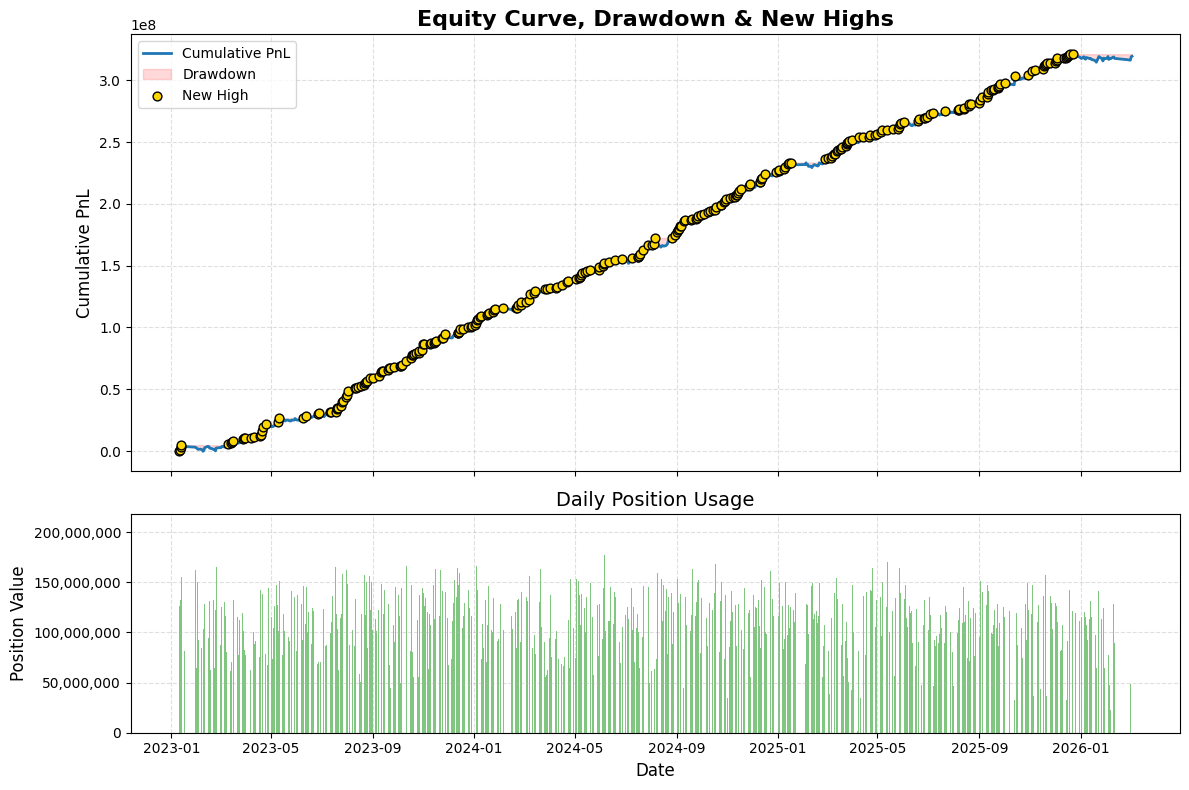


指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : 31,943.77
近一年報酬（萬）      : 8,332.65
風報比                  : 43.48
年化 Sharpe          : 5.68
創高最長費時 (天)     : 38
平均每日交易商品數   : 69.58

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: 91.39%
近一年報酬率（近一年平均部位）: 77.41%
勝率 (日/單筆)      : 60.77% / 61.78%
平均BP (單/單位)   : 37.38 / 38.0783

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -607.17 萬
MDD金額/佔平均比   : -734.69 萬 / 6.59%
平均/最大部位(萬)  : 11,155.53 / 20,734.37
平均最大單一商品比  : 2.12%



In [23]:
bt = BackTest(signalwithRisk_df)
results = bt.run_analysis()